<a href="https://colab.research.google.com/github/harshit-538/ML-DL/blob/main/6_Dropout_Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Under-fitting:**
  - too simple to explain the variance

## **Over-fitting:**
  - force fitting too good to be true
  - cannot generalize well on testing dataset


## **Dropout:**
  - Randomly dropping a% neurons

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

In [ ]:
df = pd.read_csv("sonar_dataset.csv",header=None)
df.sample(5)

,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
65,0.0176,0.0172,0.0501,0.0285,0.0262,0.0351,0.0362,0.0535,0.0258,0.0474,...,0.0042,0.0175,0.0171,0.0079,0.0050,0.0112,0.0179,0.0294,0.0063,R
47,0.0373,0.0281,0.0232,0.0225,0.0179,0.0733,0.0841,0.1031,0.0993,0.0802,...,0.0008,0.0045,0.0024,0.0006,0.0073,0.0096,0.0054,0.0085,0.0060,R
141,0.0707,0.1252,0.1447,0.1644,0.1693,0.0844,0.0715,0.0947,0.1583,0.1247,...,0.0156,0.0197,0.0135,0.0127,0.0138,0.0133,0.0131,0.0154,0.0218,M
206,0.0303,0.0353,0.0490,0.0608,0.0167,0.1354,0.1465,0.1123,0.1945,0.2354,...,0.0086,0.0046,0.0126,0.0036,0.0035,0.0034,0.0079,0.0036,0.0048,M
143,0.0516,0.0944,0.0622,0.0415,0.0995,0.2431,0.1777,0.2018,0.2611,0.1294,...,0.0432,0.0274,0.0152,0.0120,0.0129,0.0020,0.0109,0.0074,0.0078,M


In [ ]:
df.shape

(208, 61)

In [ ]:
df.isna().sum()

,0
0,0
1,0
2,0
3,0
4,0
...,...
56,0
57,0
58,0
59,0


In [7]:
df[60].value_counts()

,count
60,
M,111
R,97


In [8]:
X = df.drop(60,axis="columns")
y = df[60]

In [11]:
y = pd.get_dummies(y,drop_first=True)
y.sample(5)

,R
60,True
101,False
23,True
151,False
20,True


In [12]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=1)

In [13]:
import tensorflow as tf
from tensorflow import keras

In [15]:
model = keras.Sequential([
    keras.layers.Dense(60,input_dim=60,activation="relu"),
    keras.layers.Dense(30,activation="relu"),
    keras.layers.Dense(15,activation="relu"),
    keras.layers.Dense(1,activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.fit(X_train,y_train,epochs = 100,batch_size=8)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5504 - loss: 0.6735
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7049 - loss: 0.6289
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7150 - loss: 0.6080
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7434 - loss: 0.5696
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7772 - loss: 0.5177
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7902 - loss: 0.5225
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8265 - loss: 0.4683 
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7552 - loss: 0.4668 
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7582 - loss: 0.4111 
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8311 - loss: 0.3665 
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8179 - loss: 0.4119 
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8781

In [16]:
model.evaluate(X_test,y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7861 - loss: 0.9916 


[0.882765531539917, 0.7884615659713745]

In [19]:
y_pred = model.predict(X_test).reshape(-1)

y_pred = np.round(y_pred)
y_pred[:10]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


array([0., 1., 1., 0., 1., 1., 0., 1., 0., 1.], dtype=float32)

In [21]:
y_test[:10]

,R
186,False
155,False
165,False
200,False
58,True
34,True
151,False
18,True
202,False
62,True


In [22]:
from sklearn.metrics import confusion_matrix,classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

       False       0.75      0.89      0.81        27
        True       0.85      0.68      0.76        25

    accuracy                           0.79        52
   macro avg       0.80      0.78      0.78        52
weighted avg       0.80      0.79      0.79        52



Text(50.722222222222214, 0.5, 'Truth')

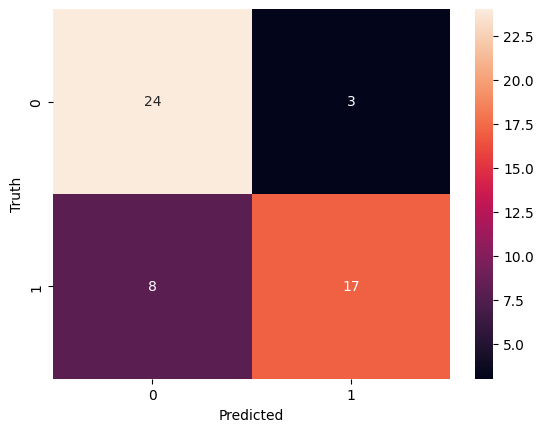

In [23]:
cm = tf.math.confusion_matrix(labels=y_test,predictions=y_pred)

sn.heatmap(cm,annot=True,fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Truth")

In [25]:
modeld = keras.Sequential([
    keras.layers.Dense(60,input_dim=60,activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(30,activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(15,activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1,activation="sigmoid")
])

modeld.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

modeld.fit(X_train,y_train,epochs = 100,batch_size=8)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5690 - loss: 0.7315
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5364 - loss: 0.7014
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4654 - loss: 0.7213 
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5271 - loss: 0.7084 
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5433 - loss: 0.6917 
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6017 - loss: 0.6888 
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4568 - loss: 0.6937 
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6268 - loss: 0.6633 
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5385 - loss: 0.6801 
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4980 - loss: 0.6810
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4527 - loss: 0.7216 
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5

In [26]:
modeld.evaluate(X_test,y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7292 - loss: 0.5677 


[0.5181018710136414, 0.75]

In [27]:
from sklearn.metrics import confusion_matrix,classification_report

y_pred = modeld.predict(X_test).reshape(-1)
y_pred = np.round(y_pred)

print(classification_report(y_test,y_pred))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
              precision    recall  f1-score   support

       False       0.73      0.81      0.77        27
        True       0.77      0.68      0.72        25

    accuracy                           0.75        52
   macro avg       0.75      0.75      0.75        52
weighted avg       0.75      0.75      0.75        52

